# IDS 705 — Group 10: DASYNet Fine-Tuning on Corrupted Data

**Pipeline:**
1. Download clean PneumoniaMNIST train+val images to Google Drive
2. Combine clean + all 5 corrupted splits (train then val) into one giant dataset
3. Fine-tune DASYNet on the combined dataset
4. Evaluate on the official PneumoniaMNIST validation split


## 0. Setup


In [1]:
!pip install medmnist --quiet

import os, re, shutil
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

import medmnist
from medmnist import INFO, PneumoniaMNIST
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'torch   : {torch.__version__}')
print(f'device  : {device}')


torch   : 2.10.0+cpu
device  : cpu


## 1. Mount Drive


In [2]:
from google.colab import drive
drive.mount('/content/drive')

# ── Paths ─────────────────────────────────────────────────────────────────────
DRIVE_ROOT       = Path('/content/drive/MyDrive/Data_Corruption')
CLEAN_DIR        = DRIVE_ROOT / 'Clean_images'          # we will create this
CORRUPT_ROOT     = DRIVE_ROOT / 'corrupt_full_image'

# The 5 corruption subfolders (each has train/ and val/ inside)
CORRUPTION_NAMES = ['gamma_under', 'gamma_over', 'fgsm', 'contrast_low', 'brightness_bright']

# MedMNIST config
DATA_FLAG  = 'pneumoniamnist'
IMG_SIZE   = 224
DATA_ROOT  = os.path.expanduser('~/.medmnist')
info       = INFO[DATA_FLAG]
n_classes  = len(info['label'])

# Fine-tuning hyperparameters
FINETUNE_EPOCHS = 5
FINETUNE_LR     = 1e-4
BATCH_SIZE      = 64

IMG_EXT = {'.png', '.jpg', '.jpeg', '.bmp', '.tiff'}

print('Paths configured.')
print(f'Corrupt subfolders: {CORRUPTION_NAMES}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Paths configured.
Corrupt subfolders: ['gamma_under', 'gamma_over', 'fgsm', 'contrast_low', 'brightness_bright']


## 2. Download Clean Train + Val Images to Drive

Downloads the official PneumoniaMNIST train and val splits at 224×224
and saves each image as a PNG into `Clean_images/train/` and `Clean_images/val/`.
Images are named `{index:05d}_label{label}.png` so labels are embedded in the filename.
Skips if folder already exists.


In [3]:
def save_split_to_drive(split, out_dir):
    """Save a medmnist split to Drive as individual PNGs."""
    out_dir = Path(out_dir)
    if out_dir.exists() and any(out_dir.rglob('*.png')):
        existing = len(list(out_dir.rglob('*.png')))
        print(f'  [SKIP] {out_dir.name} — {existing} images already saved')
        return
    out_dir.mkdir(parents=True, exist_ok=True)

    ds = PneumoniaMNIST(split=split, transform=None, download=True,
                        root=DATA_ROOT, size=IMG_SIZE)
    print(f'  Saving {len(ds)} {split} images to {out_dir}...')
    for idx in range(len(ds)):
        img_pil, label = ds[idx]
        lbl = int(label)
        fname = out_dir / f'{idx:05d}_label{lbl}.png'
        img_pil.save(str(fname))
    print(f'  Done — {len(ds)} images saved.')


print('Saving clean images to Drive...')
save_split_to_drive('train', CLEAN_DIR / 'train')
save_split_to_drive('val',   CLEAN_DIR / 'val')
print('\nClean images ready.')


Saving clean images to Drive...
  [SKIP] train — 4708 images already saved
  [SKIP] val — 524 images already saved

Clean images ready.


## 3. Combine Clean + Corrupted into One Giant Dataset

Order: **clean train → clean val → corrupt train (all 5) → corrupt val (all 5)**

Labels come from the filename (`label0` / `label1`) for clean images
and from the medmnist npz (by index order) for corrupted images.


In [4]:
# ── Label helpers ─────────────────────────────────────────────────────────────
def label_from_filename(path):
    """Extract label from filenames like 00042_label1.png"""
    m = re.search(r'label(\d+)', Path(path).stem)
    if m:
        return int(m.group(1))
    raise ValueError(f'Cannot parse label from: {path}')


def collect_from_folder(folder, label_source='filename', npz_labels=None):
    """
    Return sorted list of (Path, label) from a folder.
    label_source='filename'  -> parse label from filename
    label_source='npz'       -> use npz_labels list matched by sort order
    """
    folder = Path(folder)
    if not folder.exists():
        print(f'  [SKIP] {folder} not found')
        return []
    files = sorted([p for p in folder.rglob('*') if p.suffix.lower() in IMG_EXT],
                   key=lambda p: p.name)
    if label_source == 'filename':
        return [(p, label_from_filename(p)) for p in files]
    else:  # npz
        n = min(len(files), len(npz_labels))
        if len(files) != len(npz_labels):
            print(f'  WARNING: {folder.name} — {len(files)} imgs vs {len(npz_labels)} labels, truncating to {n}')
        return list(zip(files[:n], npz_labels[:n]))


# Load npz labels for train and val splits (for corrupted folders)
_ds_train = PneumoniaMNIST(split='train', transform=None, download=True,
                            root=DATA_ROOT, size=IMG_SIZE)
_ds_val   = PneumoniaMNIST(split='val',   transform=None, download=True,
                            root=DATA_ROOT, size=IMG_SIZE)
npz_train_labels = [int(_ds_train[i][1]) for i in range(len(_ds_train))]
npz_val_labels   = [int(_ds_val[i][1])   for i in range(len(_ds_val))]

print(f'NPZ train labels: {len(npz_train_labels)}  '
      f'(normal={npz_train_labels.count(0)}, pneumonia={npz_train_labels.count(1)})')
print(f'NPZ val labels  : {len(npz_val_labels)}  '
      f'(normal={npz_val_labels.count(0)}, pneumonia={npz_val_labels.count(1)})')


NPZ train labels: 4708  (normal=1214, pneumonia=3494)
NPZ val labels  : 524  (normal=135, pneumonia=389)


/tmp/ipykernel_16446/1125794044.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  npz_train_labels = [int(_ds_train[i][1]) for i in range(len(_ds_train))]
/tmp/ipykernel_16446/1125794044.py:37: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  npz_val_labels   = [int(_ds_val[i][1])   for i in range(len(_ds_val))]


In [5]:
# ── Collect all samples in the specified order ────────────────────────────────
all_samples = []
source_log  = []

# 1. Clean train
s = collect_from_folder(CLEAN_DIR / 'train', label_source='filename')
all_samples.extend(s)
source_log.append(('Clean train', len(s)))
print(f'Clean train      : {len(s):>5} images')

# 2. Clean val
s = collect_from_folder(CLEAN_DIR / 'val', label_source='filename')
all_samples.extend(s)
source_log.append(('Clean val', len(s)))
print(f'Clean val        : {len(s):>5} images')

# 3. Corrupted train (all 5 corruptions)
for corruption in CORRUPTION_NAMES:
    folder = CORRUPT_ROOT / corruption / 'train'
    s = collect_from_folder(folder, label_source='npz', npz_labels=npz_train_labels)
    all_samples.extend(s)
    source_log.append((f'{corruption}/train', len(s)))
    print(f'{corruption}/train : {len(s):>5} images')

# 4. Corrupted val (all 5 corruptions)
for corruption in CORRUPTION_NAMES:
    folder = CORRUPT_ROOT / corruption / 'val'
    s = collect_from_folder(folder, label_source='npz', npz_labels=npz_val_labels)
    all_samples.extend(s)
    source_log.append((f'{corruption}/val', len(s)))
    print(f'{corruption}/val   : {len(s):>5} images')

print(f'\nTotal combined   : {len(all_samples):>5} images')
all_labels = [s[1] for s in all_samples]
print(f'  Normal (0)     : {all_labels.count(0)}')
print(f'  Pneumonia (1)  : {all_labels.count(1)}')


Clean train      :  4708 images
Clean val        :   524 images
gamma_under/train :  4708 images
gamma_over/train :  4708 images
fgsm/train :  4708 images
contrast_low/train :  4708 images
brightness_bright/train :  4708 images
gamma_under/val   :   524 images
gamma_over/val   :   524 images
fgsm/val   :   524 images
contrast_low/val   :   524 images
brightness_bright/val   :   524 images

Total combined   : 31392 images
  Normal (0)     : 8094
  Pneumonia (1)  : 23298


## 4. Dataset & Transforms


In [6]:
# ── DASYNet architecture (224×224 grayscale) ──────────────────────────────────
class DASYNET(nn.Module):
    def __init__(self, in_channels=1, num_classes=2):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.global_pool = nn.AdaptiveAvgPool2d((3, 3))
        self.flatten     = nn.Flatten()
        self.classifier  = nn.Sequential(
            nn.Linear(64 * 3 * 3, 128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.global_pool(x)
        return self.classifier(self.flatten(x))


# ── Transform — matches DASYNet training exactly ──────────────────────────────
finetune_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])


class CombinedDataset(Dataset):
    """Loads (image_path, label) pairs from the combined sample list."""
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self):  return len(self.samples)

    def __getitem__(self, i):
        path, label = self.samples[i]
        img = Image.open(path).convert('L')   # grayscale
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)


ft_dataset = CombinedDataset(all_samples, transform=finetune_transform)
ft_loader  = DataLoader(ft_dataset, batch_size=BATCH_SIZE, shuffle=True,
                        num_workers=2, pin_memory=True)
print(f'Fine-tune dataset : {len(ft_dataset):,} images')
print(f'Batches per epoch : {len(ft_loader)}')


Fine-tune dataset : 31,392 images
Batches per epoch : 491


## 5. Load Pretrained DASYNet


In [7]:
WEIGHTS_FILE = '/content/drive/MyDrive/ML_final/dasynet_finetuned_partial.pth'

model = DASYNET(in_channels=1, num_classes=n_classes).to(device)
model.load_state_dict(torch.load(WEIGHTS_FILE, map_location=device))
model.eval()
print('Loaded partial checkpoint.')

Loaded partial checkpoint.


## 6. Fine-Tuning


In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=FINETUNE_LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

history = {'loss': [], 'acc': []}
print(f'Fine-tuning for {FINETUNE_EPOCHS} epochs on {len(ft_dataset):,} images...\n')

for epoch in range(FINETUNE_EPOCHS):
    model.train()
    run_loss, correct, total = 0.0, 0, 0

    for imgs, lbls in ft_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        out  = model(imgs)
        loss = criterion(out, lbls)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        run_loss += loss.item() * imgs.size(0)
        correct  += out.argmax(1).eq(lbls).sum().item()
        total    += lbls.size(0)

    e_loss = run_loss / total
    e_acc  = 100. * correct / total
    history['loss'].append(e_loss)
    history['acc'].append(e_acc)
    scheduler.step(e_loss)
    print(f'Epoch [{epoch+1:02d}/{FINETUNE_EPOCHS}]  '
          f'Loss: {e_loss:.4f}  Acc: {e_acc:.2f}%')

# Save fine-tuned weights to Drive
FT_WEIGHTS = '/content/drive/MyDrive/ML_final/dasynet_finetuned.pth'
torch.save(model.state_dict(), FT_WEIGHTS)
print(f'\nFine-tuned weights saved to: {FT_WEIGHTS}')


Fine-tuning for 5 epochs on 31,392 images...



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [01/5]  Loss: 0.0935  Acc: 96.58%
Epoch [02/5]  Loss: 0.0816  Acc: 97.02%
Epoch [03/5]  Loss: 0.0733  Acc: 97.22%
Epoch [04/5]  Loss: 0.0697  Acc: 97.42%
Epoch [05/5]  Loss: 0.0638  Acc: 97.64%

Fine-tuned weights saved to: /content/drive/MyDrive/ML_final/dasynet_finetuned.pth


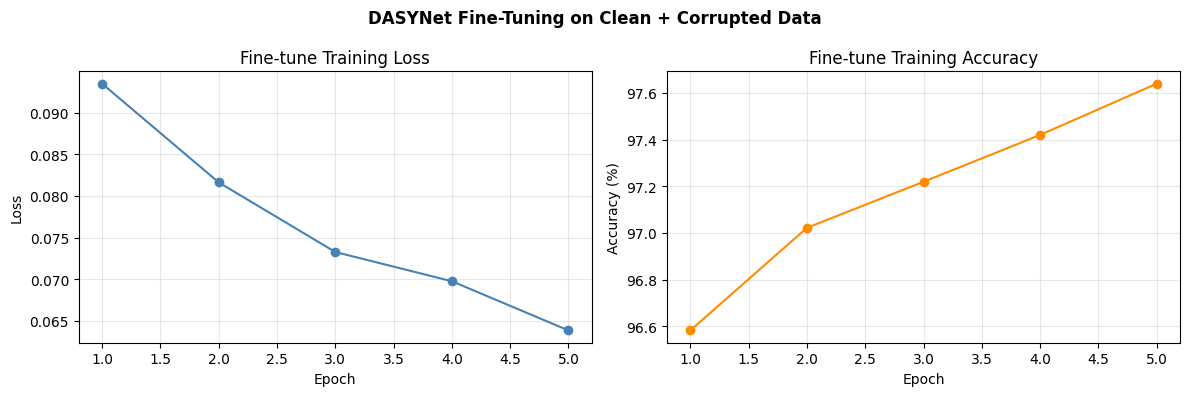

In [9]:
# Training curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
eps = range(1, FINETUNE_EPOCHS + 1)
ax1.plot(eps, history['loss'], 'o-', color='steelblue')
ax1.set_title('Fine-tune Training Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.grid(alpha=0.3)
ax2.plot(eps, history['acc'],  'o-', color='darkorange')
ax2.set_title('Fine-tune Training Accuracy')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)'); ax2.grid(alpha=0.3)
plt.suptitle('DASYNet Fine-Tuning on Clean + Corrupted Data', fontweight='bold')
plt.tight_layout()
plt.savefig('dasynet_finetune_curve.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Evaluate on Official Validation Split


In [10]:
# ── Evaluation transforms ────────────────────────────────────────────────────
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

def evaluate_samples(samples, label, transform):
    """Run model on a (path, label) sample list and return metrics dict."""
    ds     = CombinedDataset(samples, transform=transform)
    loader = DataLoader(ds, batch_size=256, shuffle=False, num_workers=2)
    preds, labels, probs = [], [], []
    model.eval()
    with torch.no_grad():
        for imgs, lbls in loader:
            logits = model(imgs.to(device))
            p      = F.softmax(logits, dim=1)
            preds.extend(logits.argmax(1).cpu().numpy())
            labels.extend(lbls.numpy())
            probs.extend(p[:, 1].cpu().numpy())
    y_pred  = np.array(preds)
    y_true  = np.array(labels)
    y_prob  = np.array(probs)
    return {
        'Split'    : label,
        'N'        : len(y_true),
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall'   : recall_score(y_true, y_pred, zero_division=0),
        'F1'       : f1_score(y_true, y_pred, zero_division=0),
        'AUROC'    : roc_auc_score(y_true, y_prob),
    }


# ── 1. Official medmnist clean val (from npz) ────────────────────────────────
val_ds     = PneumoniaMNIST(split='val', transform=val_transform,
                             download=True, root=DATA_ROOT, size=IMG_SIZE)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)
val_preds, val_labels, val_probs = [], [], []
model.eval()
with torch.no_grad():
    for imgs, lbls in val_loader:
        logits = model(imgs.to(device))
        p      = F.softmax(logits, dim=1)
        val_preds.extend(logits.argmax(1).cpu().numpy())
        val_labels.extend(lbls.squeeze().numpy())
        val_probs.extend(p[:, 1].cpu().numpy())
val_preds  = np.array(val_preds)
val_labels = np.array(val_labels)
val_probs  = np.array(val_probs)
clean_val_metrics = {
    'Split'    : 'Clean val (medmnist npz)',
    'N'        : len(val_labels),
    'Accuracy' : accuracy_score(val_labels, val_preds),
    'Precision': precision_score(val_labels, val_preds, zero_division=0),
    'Recall'   : recall_score(val_labels, val_preds, zero_division=0),
    'F1'       : f1_score(val_labels, val_preds, zero_division=0),
    'AUROC'    : roc_auc_score(val_labels, val_probs),
}

# ── 2. Corrupted val splits from Drive (each corruption separately) ──────────
eval_results = [clean_val_metrics]

for corruption in CORRUPTION_NAMES:
    folder  = CORRUPT_ROOT / corruption / 'val'
    samples = collect_from_folder(folder, label_source='npz', npz_labels=npz_val_labels)
    r       = evaluate_samples(samples, f'{corruption}/val', val_transform)
    eval_results.append(r)

# ── 3. All corrupted val combined ────────────────────────────────────────────
all_corrupt_val = []
for corruption in CORRUPTION_NAMES:
    folder  = CORRUPT_ROOT / corruption / 'val'
    samples = collect_from_folder(folder, label_source='npz', npz_labels=npz_val_labels)
    all_corrupt_val.extend(samples)
r = evaluate_samples(all_corrupt_val, 'All corrupt val (combined)', val_transform)
eval_results.append(r)

# ── Summary table ────────────────────────────────────────────────────────────
df_eval = pd.DataFrame(eval_results)
df_eval = df_eval.set_index('Split').round(4)
print('\n=== Fine-tuned DASYNet — Validation Results ===')
print(df_eval.to_string())



=== Fine-tuned DASYNet — Validation Results ===
                               N  Accuracy  Precision  Recall      F1   AUROC
Split                                                                        
Clean val (medmnist npz)     524    0.9790     0.9896  0.9820  0.9858  0.9974
gamma_under/val              524    0.9676     0.9844  0.9717  0.9780  0.9949
gamma_over/val               524    0.9790     0.9846  0.9871  0.9859  0.9969
fgsm/val                     524    0.9771     0.9846  0.9846  0.9846  0.9964
contrast_low/val             524    0.9695     0.9921  0.9666  0.9792  0.9970
brightness_bright/val        524    0.9733     0.9947  0.9692  0.9818  0.9973
All corrupt val (combined)  2620    0.9733     0.9880  0.9758  0.9819  0.9960


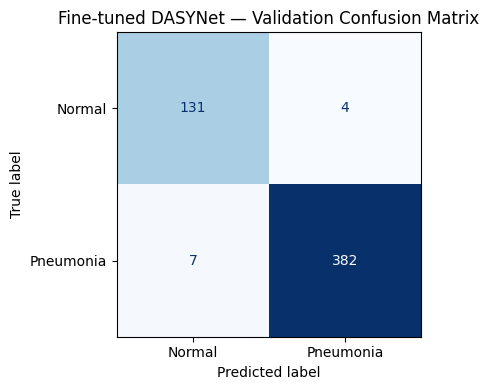

TN=131  FP=4  FN=7  TP=382


In [11]:
# Confusion matrix
cm = confusion_matrix(val_labels, val_preds)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Pneumonia']).plot(
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title('Fine-tuned DASYNet — Validation Confusion Matrix')
plt.tight_layout()
plt.savefig('dasynet_finetuned_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'TN={cm[0,0]}  FP={cm[0,1]}  FN={cm[1,0]}  TP={cm[1,1]}')


In [12]:
# Dataset composition summary
df_log = pd.DataFrame(source_log, columns=['Source', 'Count'])
df_log['Pct'] = (df_log['Count'] / df_log['Count'].sum() * 100).round(1)
print('\n=== Training Data Composition ===')
print(df_log.to_string(index=False))
print(f"Total: {df_log['Count'].sum():,} images")



=== Training Data Composition ===
                 Source  Count  Pct
            Clean train   4708 15.0
              Clean val    524  1.7
      gamma_under/train   4708 15.0
       gamma_over/train   4708 15.0
             fgsm/train   4708 15.0
     contrast_low/train   4708 15.0
brightness_bright/train   4708 15.0
        gamma_under/val    524  1.7
         gamma_over/val    524  1.7
               fgsm/val    524  1.7
       contrast_low/val    524  1.7
  brightness_bright/val    524  1.7
Total: 31,392 images


## 8. Evaluate Fine-tuned DASYNet on Corrupted Test Set

Mirrors the full-image single-attack evaluation from Notebook 2 (DASYNet Attack Study).
10 attacks × 5 levels = 50 experiments on `PneumoniaMNIST(split='test')`.
⚠️ Flag = accuracy drop > 5% from the fine-tuned model's clean test baseline.

In [13]:
# ── Re-define attack infrastructure if not already in scope ──────────────────
import io
from itertools import combinations

ATTACK_LEVELS = {
    'Gaussian Blur'      : [(3,0.5),(7,1.0),(11,2.0),(15,3.0),(21,5.0)],
    'Downsampling'       : [0.5, 0.4, 0.3, 0.2, 0.1],
    'JPEG'               : [75, 50, 30, 15, 5],
    'Brightness Dark'    : [-0.1,-0.2,-0.3,-0.4,-0.5],
    'Brightness Bright'  : [0.1, 0.2, 0.3, 0.4, 0.5],
    'Contrast Low'       : [0.8, 0.6, 0.4, 0.3, 0.2],
    'Contrast High'      : [1.2, 1.4, 1.6, 1.8, 2.0],
    'Gamma Overexposed'  : [0.9, 0.7, 0.5, 0.3, 0.1],
    'Gamma Underexposed' : [1.5, 2.0, 3.0, 4.0, 5.0],
    'FGSM'               : [0.001, 0.005, 0.01, 0.015, 0.02],
}
ATTACK_NAMES = ['FGSM', 'Gamma Underexposed', 'Contrast Low', 'Gamma Overexposed', 'Brightness Bright']

RECALL_DANGER_THRESHOLD = 0.90
ROBUST_THRESHOLD        = 0.02
CONCERNING_THRESHOLD    = 0.05

def jpeg_compress_pil(img, quality):
    buf = io.BytesIO()
    img.save(buf, format='JPEG', quality=quality)
    buf.seek(0)
    return Image.open(buf).copy()

def apply_gamma(t, gamma):
    t_01    = (t + 1) / 2
    t_gamma = torch.pow(t_01.clamp(min=1e-8), gamma)
    return (t_gamma * 2 - 1).clamp(-1, 1)

def make_clean_transform():
    return transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=Image.NEAREST),
        transforms.Lambda(lambda img: img.convert('L')),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])

def make_single_transform(attack_name, level_idx):
    if attack_name == 'FGSM':
        return None
    param = ATTACK_LEVELS[attack_name][level_idx]
    pil_steps = [
        transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=Image.NEAREST),
        transforms.Lambda(lambda img: img.convert('L')),
    ]
    tensor_steps = []
    if attack_name == 'Gaussian Blur':
        ks, sig = param
        pil_steps.append(transforms.GaussianBlur(kernel_size=ks, sigma=sig))
    elif attack_name == 'Downsampling':
        small = max(1, int(IMG_SIZE * param))
        pil_steps.append(transforms.Resize((small, small), interpolation=Image.NEAREST))
        pil_steps.append(transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=Image.NEAREST))
    elif attack_name == 'JPEG':
        pil_steps.append(transforms.Lambda(lambda img, q=param: jpeg_compress_pil(img, q)))
    elif attack_name in ('Brightness Dark', 'Brightness Bright'):
        tensor_steps.append(transforms.Lambda(lambda t, d=param: torch.clamp(t + d, -1.0, 1.0)))
    elif attack_name in ('Contrast Low', 'Contrast High'):
        tensor_steps.append(transforms.Lambda(lambda t, a=param: torch.clamp(t * a, -1.0, 1.0)))
    elif attack_name in ('Gamma Overexposed', 'Gamma Underexposed'):
        tensor_steps.append(transforms.Lambda(lambda t, g=param: apply_gamma(t, g)))
    return transforms.Compose(
        pil_steps +
        [transforms.ToTensor(), transforms.Normalize(mean=[0.5], std=[0.5])] +
        tensor_steps
    )

def make_loader(transform):
    ds = PneumoniaMNIST(
        split='test', transform=transform,
        download=False, root=DATA_ROOT, size=IMG_SIZE
    )
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

def run_inference(model, loader):
    model.eval()
    all_scores, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            logits = model(images.to(device))
            scores = torch.softmax(logits, dim=1)
            all_scores.append(scores.cpu().numpy())
            all_labels.append(labels.numpy())
    return np.concatenate(all_scores), np.concatenate(all_labels)

def run_fgsm_inference(model, epsilon):
    clean_tfm = make_clean_transform()
    ds     = PneumoniaMNIST(split='test', transform=clean_tfm,
                            download=False, root=DATA_ROOT, size=IMG_SIZE)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    criterion = nn.CrossEntropyLoss()
    model.eval()
    all_scores, all_labels = [], []
    for images, labels in loader:
        images   = images.to(device).requires_grad_(True)
        labels_t = labels.squeeze().long().to(device)
        loss     = criterion(model(images), labels_t)
        model.zero_grad()
        loss.backward()
        perturbed = torch.clamp(images + epsilon * images.grad.sign(), -1.0, 1.0).detach()
        with torch.no_grad():
            scores = torch.softmax(model(perturbed), dim=1)
        all_scores.append(scores.cpu().numpy())
        all_labels.append(labels.numpy())
    return np.concatenate(all_scores), np.concatenate(all_labels)

def compute_metrics(y_score, y_true):
    from medmnist import Evaluator
    evaluator = Evaluator(DATA_FLAG, 'test', size=IMG_SIZE)
    auc, acc  = evaluator.evaluate(y_score, save_folder=None, run=None)
    y_pred    = (y_score[:, 1] >= 0.5).astype(int)
    y_true_f  = y_true.flatten().astype(int)
    return {
        'accuracy' : float(acc),
        'auroc'    : float(auc),
        'precision': precision_score(y_true_f, y_pred, zero_division=0),
        'recall'   : recall_score(y_true_f, y_pred, zero_division=0),
        'f1'       : f1_score(y_true_f, y_pred, zero_division=0),
    }

def verdict(acc_drop):
    if acc_drop < ROBUST_THRESHOLD:        return 'ROBUST'
    elif acc_drop < CONCERNING_THRESHOLD:  return 'CONCERNING'
    else:                                  return 'VULNERABLE'

print('Attack infrastructure ready ✓')

Attack infrastructure ready ✓


### Clean test baseline (fine-tuned model)

In [14]:
# ── Clean test baseline (fine-tuned model) ───────────────────────────────────
print('Evaluating fine-tuned DASYNet on clean test set...')
clean_loader          = make_loader(make_clean_transform())
y_score_clean, y_true = run_inference(model, clean_loader)
baseline              = compute_metrics(y_score_clean, y_true)

print('\n=== Clean Test Baseline — Fine-tuned DASYNet ===')
for k, v in baseline.items():
    print(f'  {k:12s}: {v:.4f}')

Evaluating fine-tuned DASYNet on clean test set...

=== Clean Test Baseline — Fine-tuned DASYNet ===
  accuracy    : 0.8974
  auroc       : 0.9669
  precision   : 0.8671
  recall      : 0.9872
  f1          : 0.9233


In [15]:
# ── 5 attacks × 5 levels on full test images ────────────────────────────────
single_results = {}
total = len(ATTACK_NAMES) * 5
done  = 0

for attack_name in ATTACK_NAMES:
    print(f'\n--- {attack_name} ---')
    single_results[attack_name] = {}

    for level_idx in range(5):
        if attack_name == 'FGSM':
            epsilon        = ATTACK_LEVELS['FGSM'][level_idx]
            y_score, _     = run_fgsm_inference(model, epsilon)
        else:
            tfm            = make_single_transform(attack_name, level_idx)
            loader         = make_loader(tfm)
            y_score, _     = run_inference(model, loader)

        m        = compute_metrics(y_score, y_true)
        single_results[attack_name][level_idx + 1] = m
        done    += 1
        acc_drop = baseline['accuracy'] - m['accuracy']
        flag     = '  ⚠️  FLAGGED (>5% drop)' if acc_drop > 0.05 else ''
        print(f'  L{level_idx+1}: Acc={m["accuracy"]:.4f}  '
              f'F1={m["f1"]:.4f}  AUROC={m["auroc"]:.4f}  '
              f'Recall={m["recall"]:.4f}  Drop={acc_drop:.4f}'
              f'  [{done}/{total}]{flag}')

print('\n✓ Corrupted test evaluation complete')


--- FGSM ---
  L1: Acc=0.7067  F1=0.7923  AUROC=0.7394  Recall=0.8949  Drop=0.1907  [1/25]  ⚠️  FLAGGED (>5% drop)
  L2: Acc=0.0625  F1=0.1150  AUROC=0.0025  Recall=0.0974  Drop=0.8349  [2/25]  ⚠️  FLAGGED (>5% drop)
  L3: Acc=0.0128  F1=0.0253  AUROC=0.0000  Recall=0.0205  Drop=0.8846  [3/25]  ⚠️  FLAGGED (>5% drop)
  L4: Acc=0.0096  F1=0.0190  AUROC=0.0000  Recall=0.0154  Drop=0.8878  [4/25]  ⚠️  FLAGGED (>5% drop)
  L5: Acc=0.0144  F1=0.0284  AUROC=0.0000  Recall=0.0231  Drop=0.8830  [5/25]  ⚠️  FLAGGED (>5% drop)

--- Gamma Underexposed ---
  L1: Acc=0.9054  F1=0.9290  AUROC=0.9643  Recall=0.9897  Drop=-0.0080  [6/25]
  L2: Acc=0.8878  F1=0.9167  AUROC=0.9630  Recall=0.9872  Drop=0.0096  [7/25]
  L3: Acc=0.8718  F1=0.9050  AUROC=0.9558  Recall=0.9769  Drop=0.0256  [8/25]
  L4: Acc=0.8686  F1=0.9021  AUROC=0.9429  Recall=0.9692  Drop=0.0288  [9/25]
  L5: Acc=0.8381  F1=0.8805  AUROC=0.9224  Recall=0.9538  Drop=0.0593  [10/25]  ⚠️  FLAGGED (>5% drop)

--- Contrast Low ---
  L1: Acc=

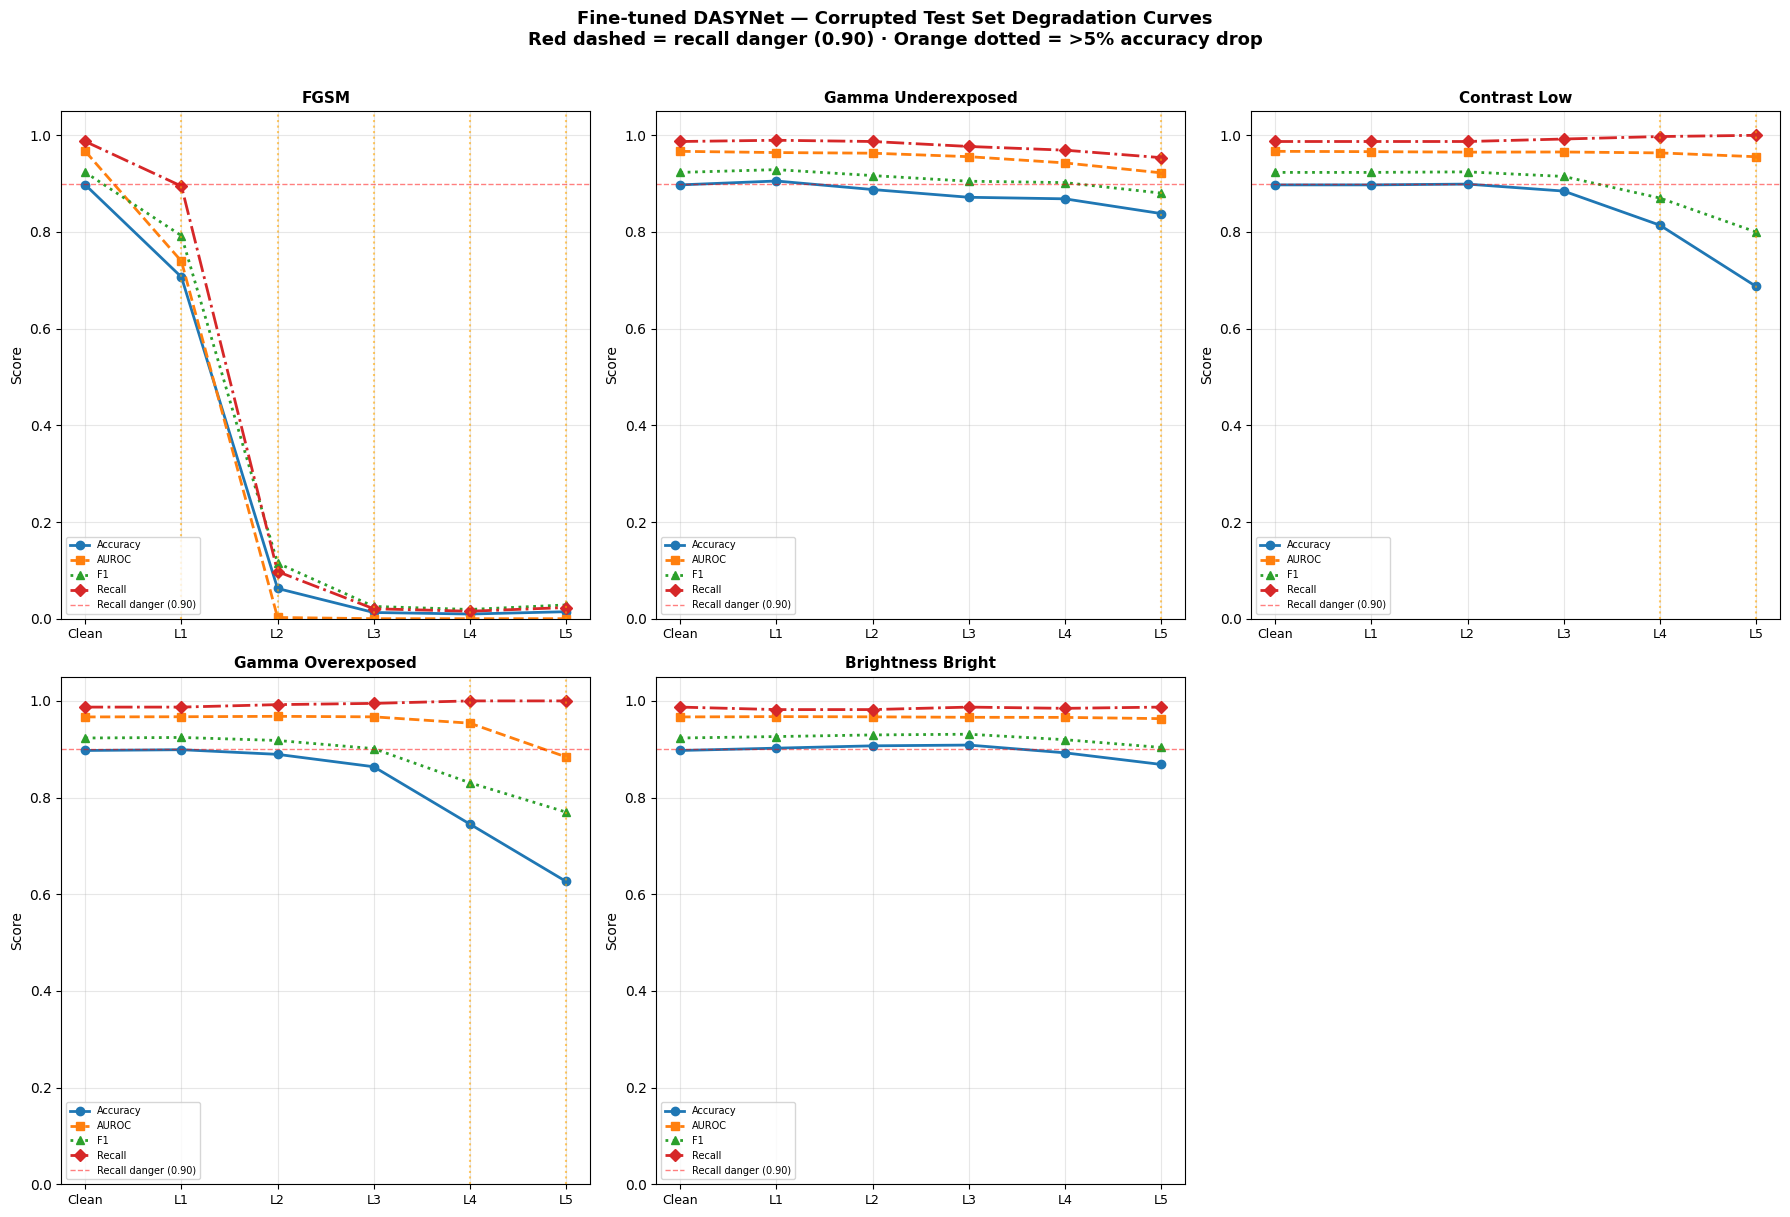


=== Fine-tuned DASYNet — Attack Ranking (worst → best) ===
                    L5 Acc  Acc Drop  L5 Recall  L5 AUROC   L5 F1     Verdict Clinical Risk
Attack                                                                                     
FGSM                0.0144    0.8830     0.0231    0.0000  0.0284  VULNERABLE          HIGH
Gamma Overexposed   0.6266    0.2708     1.0000    0.8842  0.7700  VULNERABLE           LOW
Contrast Low        0.6875    0.2099     1.0000    0.9557  0.8000  VULNERABLE           LOW
Gamma Underexposed  0.8381    0.0593     0.9538    0.9224  0.8805  VULNERABLE           LOW
Brightness Bright   0.8686    0.0288     0.9872    0.9633  0.9038  CONCERNING           LOW

Saved: finetuned_dasynet_ranking.csv


In [16]:
# ── Degradation curves ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes      = axes.flatten()
x_pos     = list(range(6))
x_labels  = ['Clean', 'L1', 'L2', 'L3', 'L4', 'L5']
styles    = [('o-','tab:blue'),('s--','tab:orange'),('^:','tab:green'),('D-.','tab:red')]
metrics_to_plot = ['accuracy', 'auroc', 'f1', 'recall']

for idx, attack_name in enumerate(ATTACK_NAMES):
    ax            = axes[idx]
    level_results = single_results[attack_name]
    series = {
        m: [baseline[m]] + [level_results[l][m] for l in range(1, 6)]
        for m in metrics_to_plot
    }
    for (style, color), (metric, values) in zip(styles, series.items()):
        ax.plot(x_pos, values, style, color=color,
                label=metric.upper() if metric == 'auroc' else metric.capitalize(),
                linewidth=2, markersize=6)
    for l_idx, level in enumerate(range(1, 6)):
        if baseline['accuracy'] - level_results[level]['accuracy'] > 0.05:
            ax.axvline(x=l_idx+1, color='orange', linestyle=':', linewidth=1.5, alpha=0.6)
    ax.axhline(y=RECALL_DANGER_THRESHOLD, color='red', linestyle='--',
               linewidth=1, alpha=0.5, label='Recall danger (0.90)')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, fontsize=9)
    ax.set_title(attack_name, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

for idx in range(len(ATTACK_NAMES), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle(
    'Fine-tuned DASYNet — Corrupted Test Set Degradation Curves\n'
    'Red dashed = recall danger (0.90) · Orange dotted = >5% accuracy drop',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('finetuned_dasynet_degradation_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Ranking table ─────────────────────────────────────────────────────────────
ranking_rows = []
for attack_name in ATTACK_NAMES:
    m_l5     = single_results[attack_name][5]
    acc_drop = baseline['accuracy'] - m_l5['accuracy']
    ranking_rows.append({
        'Attack'       : attack_name,
        'L5 Acc'       : round(m_l5['accuracy'], 4),
        'Acc Drop'     : round(acc_drop, 4),
        'L5 Recall'    : round(m_l5['recall'], 4),
        'L5 AUROC'     : round(m_l5['auroc'], 4),
        'L5 F1'        : round(m_l5['f1'], 4),
        'Verdict'      : verdict(acc_drop),
        'Clinical Risk': 'HIGH' if m_l5['recall'] < RECALL_DANGER_THRESHOLD else 'LOW',
    })

df_ranking = pd.DataFrame(ranking_rows).sort_values('Acc Drop', ascending=False).set_index('Attack')
df_ranking.to_csv('finetuned_dasynet_ranking.csv')
print('\n=== Fine-tuned DASYNet — Attack Ranking (worst → best) ===')
print(df_ranking.to_string())
print('\nSaved: finetuned_dasynet_ranking.csv')